In [ ]:
!pip install datasets pillow torch transformers scikit-learn joblib tqdm

Imports and Setup

In [21]:
import os
import random
import joblib
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset, load_from_disk
from transformers import CLIPProcessor, CLIPModel, get_linear_schedule_with_warmup

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


Load Dataset

In [6]:
#!rm -rf /content/drive

In [7]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/flickr30k_data"
os.makedirs(DATA_DIR, exist_ok=True)

print("Dataset folder ready:", DATA_DIR)
from datasets import load_dataset

ds = load_dataset(
    "AnyModal/flickr30k",
    split="train",
    cache_dir=DATA_DIR
)

print("Dataset loaded and cached.")


Mounted at /content/drive
Dataset folder ready: /content/drive/MyDrive/flickr30k_data


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/762 [00:00<?, ?B/s]

Dataset loaded and cached.


Future Data Loads / No need to download data again

In [ ]:
from datasets import load_from_disk
ds = load_from_disk(DATA_DIR + "/arrow_dataset")

Build caption-level dataframe using all 5 captions

In [8]:
rows = []

for image_id in range(len(ds)):
    captions = ds[image_id][CAPTION_KEY]
    for caption_idx, caption in enumerate(captions):
        rows.append({
            "image_id": image_id,
            "caption_idx": caption_idx,
            "caption": caption
        })

pairs_df = pd.DataFrame(rows)
print("Total positive image-caption pairs:", len(pairs_df))
pairs_df.head()

Total positive image-caption pairs: 145000


,image_id,caption_idx,caption
0,0,0,Two young guys with shaggy hair look at their ...
1,0,1,"Two young, White males are outside near many b..."
2,0,2,Two men in green shirts are standing in a yard.
3,0,3,A man in a blue shirt standing in a garden.
4,0,4,Two friends enjoy time spent together.


Split by image_id to avoid leakage

In [9]:
all_image_ids = np.arange(len(ds))

train_img_ids, val_img_ids = train_test_split(
    all_image_ids,
    test_size=0.2,
    random_state=SEED
)

train_img_ids = set(train_img_ids)
val_img_ids = set(val_img_ids)

train_df = pairs_df[pairs_df["image_id"].isin(train_img_ids)].reset_index(drop=True)
val_df   = pairs_df[pairs_df["image_id"].isin(val_img_ids)].reset_index(drop=True)

print("Train pairs:", len(train_df))
print("Val pairs  :", len(val_df))
print("Train images:", len(train_img_ids))
print("Val images  :", len(val_img_ids))

Train pairs: 116000
Val pairs  : 29000
Train images: 23200
Val images  : 5800


Load CLIP

In [10]:
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

clip_model.eval()

for param in clip_model.parameters():
    param.requires_grad = False

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Extract Image embeddings

In [11]:
def get_image_embeddings(dataset):
    image_embeddings = {}

    for i in tqdm(range(len(dataset)), desc="Encoding images"):
        image = dataset[i]["image"]

        inputs = clip_processor(images=image, return_tensors="pt").to(DEVICE)

        with torch.no_grad():
            outputs = clip_model.vision_model(**inputs)
            pooled = outputs.pooler_output  # (1, hidden_dim)

            emb = clip_model.visual_projection(pooled)  # (1, 512)
            emb = emb / emb.norm(dim=-1, keepdim=True)

        image_embeddings[i] = emb.cpu().numpy().squeeze()

    return image_embeddings

Extract Text Embeddings

In [12]:
def get_text_embeddings(captions, image_ids):
    all_embeddings = []
    all_img_ids = []

    for caption, img_id in tqdm(zip(captions, image_ids), total=len(captions), desc="Encoding texts"):
        inputs = clip_processor(
            text=[caption],
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=77
        ).to(DEVICE)

        with torch.no_grad():
            outputs = clip_model.text_model(**inputs)
            pooled = outputs.pooler_output  # (1, hidden_dim)

            emb = clip_model.text_projection(pooled)  # (1, 512)
            emb = emb / emb.norm(dim=-1, keepdim=True)

        all_embeddings.append(emb.cpu().numpy().squeeze())
        all_img_ids.append(img_id)

    return np.array(all_embeddings), np.array(all_img_ids)

Replacement Dictionaries

In [13]:
OBJECT_MAP = {
    "horse": ["donkey", "cow", "dog", "camel"],
    "dog": ["cat", "wolf", "fox"],
    "man": ["woman", "child", "person"],
    "woman": ["man", "person"],
    "car": ["truck", "bus", "bike"],
    "bike": ["motorcycle", "scooter"],
    "bird": ["plane", "kite"],
}

COLOR_MAP = {
    "white": ["black", "brown", "pink", "gray"],
    "black": ["white", "gray", "brown"],
    "brown": ["black", "white", "gray"],
    "red": ["blue", "green", "yellow"],
    "blue": ["red", "green"],
    "green": ["yellow", "brown"],
}

ACTION_MAP = {
    "running": ["standing", "walking", "jumping", "resting"],
    "walking": ["running", "standing"],
    "standing": ["sitting", "running"],
    "sitting": ["standing", "lying"],
    "jumping": ["standing", "running"],
    "swimming": ["running", "standing"],
    "riding": ["standing", "walking"],
}

ENV_MAP = {
    "grass": ["road", "sand", "water"],
    "field": ["street", "beach"],
    "beach": ["grass", "road"],
    "water": ["land", "sand"],
    "snow": ["grass", "sand"],
    "road": ["field", "grass"],
}

COUNT_MAP = {
    "one": ["two", "three"],
    "two": ["one", "three"],
    "three": ["one", "two"],
    "a": ["two", "many"],
}

POSITION_MAP = {
    "left": ["right"],
    "right": ["left"],
    "top": ["bottom"],
    "front": ["back"],
    "behind": ["in front of"],
}

SIZE_MAP = {
    "big": ["small"],
    "small": ["big"],
    "tall": ["short"],
    "short": ["tall"],
}

ALL_MAPS = {
    **OBJECT_MAP,
    **COLOR_MAP,
    **ACTION_MAP,
    **ENV_MAP,
    **COUNT_MAP,
    **POSITION_MAP,
    **SIZE_MAP
}

Attribute Negative Generator

In [14]:
def generate_attribute_negatives(caption, max_neg=3):
    words = caption.lower().split()
    negatives = []

    for i, word in enumerate(words):
        if word in ALL_MAPS:
            for rep in ALL_MAPS[word]:
                new_words = words.copy()
                new_words[i] = rep
                negatives.append(" ".join(new_words))

    # multi-attribute corruption
    if len(words) > 3:
        for _ in range(2):
            new_words = words.copy()
            for i, word in enumerate(new_words):
                if word in ALL_MAPS and np.random.rand() < 0.3:
                    new_words[i] = np.random.choice(ALL_MAPS[word])
            negatives.append(" ".join(new_words))

    negatives = list(set(negatives))
    return negatives[:max_neg]

Build Training Pairs

In [15]:
def build_mlp_pairs_v3(
    image_embeddings_dict,
    text_embeddings,
    text_img_ids,
    captions
):
    text_embeddings = np.asarray(text_embeddings, dtype=np.float32)
    text_img_ids = np.asarray(text_img_ids)

    nn_index = NearestNeighbors(
        n_neighbors=30,
        metric="cosine",
        algorithm="brute"
    )
    nn_index.fit(text_embeddings)

    Vi, Vt, labels = [], [], []

    image_ids = sorted(image_embeddings_dict.keys())

    for image_id in tqdm(image_ids, desc="Building training pairs"):
        img_emb = image_embeddings_dict[image_id].reshape(1, -1)

        pos_indices = np.where(text_img_ids == image_id)[0]
        if len(pos_indices) == 0:
            continue

        _, indices = nn_index.kneighbors(img_emb)
        candidate_indices = indices[0]

        hard_neg = [idx for idx in candidate_indices if text_img_ids[idx] != image_id][:10]
        semi_hard = [idx for idx in candidate_indices[10:20] if text_img_ids[idx] != image_id]

        for pos_idx in pos_indices:
            # Positive pair
            Vi.append(image_embeddings_dict[image_id])
            Vt.append(text_embeddings[pos_idx])
            labels.append(1)

            # Hard negatives
            for neg_idx in hard_neg[:2]:
                Vi.append(image_embeddings_dict[image_id])
                Vt.append(text_embeddings[neg_idx])
                labels.append(0)

            # Semi-hard negatives
            for neg_idx in semi_hard[:1]:
                Vi.append(image_embeddings_dict[image_id])
                Vt.append(text_embeddings[neg_idx])
                labels.append(0)

            # Attribute negatives
            caption = captions[pos_idx]
            attr_negs = generate_attribute_negatives(caption)

            if len(attr_negs) > 0:
                inputs = clip_processor(
                    text=attr_negs,
                    return_tensors="pt",
                    padding=True,
                    truncation=True,
                    max_length=77
                ).to(DEVICE)

                with torch.no_grad():
                    text_outputs = clip_model.text_model(
                        input_ids=inputs["input_ids"],
                        attention_mask=inputs["attention_mask"]
                    )
                    pooled = text_outputs.pooler_output
                    neg_embeds = clip_model.text_projection(pooled)
                    neg_embeds = neg_embeds / neg_embeds.norm(dim=-1, keepdim=True)

                neg_embeds = neg_embeds.cpu().numpy()

                for neg_emb in neg_embeds:
                    Vi.append(image_embeddings_dict[image_id])
                    Vt.append(neg_emb)
                    labels.append(0)

    return (
        np.array(Vi, dtype=np.float32),
        np.array(Vt, dtype=np.float32),
        np.array(labels, dtype=np.int64)
    )

Feature Engineering

In [28]:
def build_features(Vi, Vt):
    diff = np.abs(Vi - Vt)
    prod = Vi * Vt

    Vi_norm = Vi / (np.linalg.norm(Vi, axis=1, keepdims=True) + 1e-10)
    Vt_norm = Vt / (np.linalg.norm(Vt, axis=1, keepdims=True) + 1e-10)

    cos_sim = np.sum(Vi_norm * Vt_norm, axis=1, keepdims=True)

    return np.concatenate([diff, prod, cos_sim], axis=1)

MLP Model and Training

In [22]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

def train_mlp(X, y, epochs=10, batch_size=256, lr=1e-3):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = MLP(X.shape[1])
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(loader):.4f}")

    return model

Image and Text Embeddings

In [30]:
# ================= STEP 1: EMBEDDINGS =================

image_embeddings = get_image_embeddings(ds)

captions = pairs_df["caption"].tolist()
image_ids = pairs_df["image_id"].tolist()

text_embeddings, text_img_ids = get_text_embeddings(captions, image_ids)

print("Image embeddings:", len(image_embeddings))
print("Text embeddings:", text_embeddings.shape)
print("Text img ids:", text_img_ids.shape)

# SAVE (so you never redo this)
import numpy as np

np.save("/content/image_embeddings.npy", image_embeddings)
np.save("/content/text_embeddings.npy", text_embeddings)
np.save("/content/text_img_ids.npy", text_img_ids)

print("Embeddings saved")

Encoding images:   0%|          | 0/29000 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/145000 [00:00<?, ?it/s]

Image embeddings: 29000
Text embeddings: (145000, 512)
Text img ids: (145000,)
Embeddings saved


Build Pairs

In [31]:
# ================= STEP 2: BUILD PAIRS =================

import numpy as np

def build_mlp_pairs(image_embeddings_dict, text_embeddings, text_img_ids, K=1):
    Vi, Vt, labels = [], [], []

    n_texts = len(text_embeddings)

    for img_id, img_emb in image_embeddings_dict.items():

        pos_indices = np.where(text_img_ids == img_id)[0]
        if len(pos_indices) == 0:
            continue

        # positives
        for pos_idx in pos_indices:
            Vi.append(img_emb)
            Vt.append(text_embeddings[pos_idx])
            labels.append(1)

        # negatives
        for _ in range(len(pos_indices) * K):
            while True:
                neg_idx = np.random.randint(0, n_texts)
                if text_img_ids[neg_idx] != img_id:
                    break

            Vi.append(img_emb)
            Vt.append(text_embeddings[neg_idx])
            labels.append(0)

    Vi = np.array(Vi, dtype=np.float32)
    Vt = np.array(Vt, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)

    return Vi, Vt, labels


Vi, Vt, labels = build_mlp_pairs(
    image_embeddings,
    text_embeddings,
    text_img_ids,
    K=1
)

print("Vi:", Vi.shape)
print("Vt:", Vt.shape)
print("labels:", labels.shape)

# SAVE
np.save("/content/Vi.npy", Vi)
np.save("/content/Vt.npy", Vt)
np.save("/content/labels.npy", labels)

print("Pairs saved")

Vi: (290000, 512)
Vt: (290000, 512)
labels: (290000,)
Pairs saved


Features

In [32]:
# ================= STEP 3: FEATURES =================

import numpy as np

def build_features(Vi, Vt):
    diff = np.abs(Vi - Vt)
    prod = Vi * Vt

    Vi_norm = Vi / (np.linalg.norm(Vi, axis=1, keepdims=True) + 1e-10)
    Vt_norm = Vt / (np.linalg.norm(Vt, axis=1, keepdims=True) + 1e-10)

    cos_sim = np.sum(Vi_norm * Vt_norm, axis=1, keepdims=True)

    return np.concatenate([diff, prod, cos_sim], axis=1).astype(np.float32)

X = build_features(Vi, Vt)
y = labels.astype(np.float32)

print("X:", X.shape)
print("y:", y.shape)

X: (290000, 1025)
y: (290000,)


Train and Evaluate

In [33]:
# ================= STEP 4: TRAIN + EVAL =================

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


def train_mlp(X, y, epochs=10, batch_size=128):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = MLP(X.shape[1]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCELoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(loader):.4f}")

    return model


mlp_model = train_mlp(X, y)


# ===== Evaluation =====

mlp_model.eval()

dataset = TensorDataset(torch.tensor(X, dtype=torch.float32))
loader = DataLoader(dataset, batch_size=1024)

all_preds = []

with torch.no_grad():
    for (xb,) in loader:
        xb = xb.to(device)
        preds = mlp_model(xb).cpu().numpy()
        all_preds.append(preds)

preds = np.vstack(all_preds).flatten()

# threshold tuning
thresholds = np.linspace(0.1, 0.9, 50)

best_f1 = 0
best_thresh = 0.5

for t in thresholds:
    pred_labels = (preds >= t).astype(int)
    f1 = f1_score(y, pred_labels)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best Threshold:", best_thresh)

pred_labels = (preds >= best_thresh).astype(int)

print("Accuracy:", accuracy_score(y, pred_labels))
print("Precision:", precision_score(y, pred_labels))
print("Recall:", recall_score(y, pred_labels))
print("F1:", f1_score(y, pred_labels))
print("ROC-AUC:", roc_auc_score(y, preds))

Epoch 1/10, Loss: 0.1059
Epoch 2/10, Loss: 0.0791
Epoch 3/10, Loss: 0.0773
Epoch 4/10, Loss: 0.0751
Epoch 5/10, Loss: 0.0738
Epoch 6/10, Loss: 0.0728
Epoch 7/10, Loss: 0.0714
Epoch 8/10, Loss: 0.0700
Epoch 9/10, Loss: 0.0684
Epoch 10/10, Loss: 0.0676
Best Threshold: 0.7040816326530612
Accuracy: 0.9791517241379311
Precision: 0.975563678179802
Recall: 0.9829241379310345
F1: 0.9792300768823816
ROC-AUC: 0.997626365826397


In [35]:
print(type(X), X.shape)
print(type(y), y.shape)

<class 'numpy.ndarray'> (290000, 1025)
<class 'numpy.ndarray'> (290000,)


Implementing Test Train Split and Training Again

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (232000, 1025)
X_test : (58000, 1025)
y_train: (232000,)
y_test : (58000,)


In [37]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


def train_mlp(X_train, y_train, epochs=10, batch_size=128, lr=1e-3):
    X_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = MLP(X_train.shape[1]).to(device)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss / len(loader):.4f}")

    return model

In [38]:
mlp_model = train_mlp(X_train, y_train)

Epoch 1/10, Loss: 0.1139
Epoch 2/10, Loss: 0.0800
Epoch 3/10, Loss: 0.0769
Epoch 4/10, Loss: 0.0756
Epoch 5/10, Loss: 0.0741
Epoch 6/10, Loss: 0.0732
Epoch 7/10, Loss: 0.0717
Epoch 8/10, Loss: 0.0708
Epoch 9/10, Loss: 0.0695
Epoch 10/10, Loss: 0.0680


In [39]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

mlp_model.eval()

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
test_dataset = TensorDataset(X_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

all_preds = []

with torch.no_grad():
    for (xb,) in test_loader:
        xb = xb.to(device)
        preds_batch = mlp_model(xb).cpu().numpy()
        all_preds.append(preds_batch)

preds = np.vstack(all_preds).flatten()

thresholds = np.linspace(0.1, 0.9, 50)
best_f1 = 0
best_thresh = 0.5

for t in thresholds:
    pred_labels = (preds >= t).astype(int)
    f1 = f1_score(y_test, pred_labels)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best Threshold:", best_thresh)

pred_labels = (preds >= best_thresh).astype(int)

print("Accuracy:", accuracy_score(y_test, pred_labels))
print("Precision:", precision_score(y_test, pred_labels))
print("Recall:", recall_score(y_test, pred_labels))
print("F1:", f1_score(y_test, pred_labels))
print("ROC-AUC:", roc_auc_score(y_test, preds))

Best Threshold: 0.589795918367347
Accuracy: 0.9758275862068966
Precision: 0.9708592097181464
Recall: 0.981103448275862
F1: 0.9759544472267005
ROC-AUC: 0.99680457431629


Saving Model

In [40]:
import torch
import json

torch.save(mlp_model.state_dict(), "/content/mlp_model_v2.pth")

with open("/content/best_threshold.json", "w") as f:
    json.dump({"best_threshold": float(0.589795918367347)}, f)

print("Model and threshold saved.")

Model and threshold saved.


Manual Testing

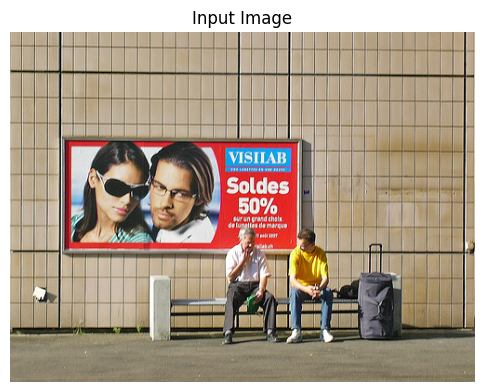

Caption: two men fighting on a bench
Match Probability: 0.030229106545448303
Prediction: NOT MATCH


In [60]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
threshold = 0.5898   # best threshold from your test results

# -----------------------------
# FEATURE BUILDER FOR ONE PAIR
# -----------------------------
def build_features_single(v_img, v_txt):
    diff = np.abs(v_img - v_txt)
    prod = v_img * v_txt

    v_img_norm = v_img / (np.linalg.norm(v_img) + 1e-10)
    v_txt_norm = v_txt / (np.linalg.norm(v_txt) + 1e-10)

    cos_sim = np.sum(v_img_norm * v_txt_norm)

    features = np.concatenate([diff, prod, [cos_sim]]).astype(np.float32)
    return features

# -----------------------------
# PREDICT FUNCTION
# -----------------------------
def predict_caption_match(image, caption, clip_processor, clip_model, mlp_model, device, threshold=0.5898):
    clip_model.eval()
    mlp_model.eval()

    inputs = clip_processor(
        images=image,
        text=[caption],
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(device)

    with torch.no_grad():
        outputs = clip_model(**inputs)

        # get embeddings
        v_img = outputs.image_embeds[0].detach().cpu().numpy()
        v_txt = outputs.text_embeds[0].detach().cpu().numpy()

        # build features exactly like training
        features = build_features_single(v_img, v_txt)

        # mlp prediction
        features_tensor = torch.tensor(features, dtype=torch.float32).unsqueeze(0).to(device)
        prob = mlp_model(features_tensor).item()

    label = "MATCH" if prob >= threshold else "NOT MATCH"
    return prob, label

# -----------------------------
# TEST EXAMPLE
# -----------------------------
sample_idx = 92
image = ds[sample_idx]["image"]
caption = "two men fighting on a bench"

# show image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

print("Caption:", caption)

prob, label = predict_caption_match(
    image=image,
    caption=caption,
    clip_processor=clip_processor,
    clip_model=clip_model,
    mlp_model=mlp_model,
    device=device,
    threshold=threshold
)

print("Match Probability:", prob)
print("Prediction:", label)